### **The Stress Testing Framework & Reasoning**

We bridged Basel III banking regulations onto the two stablecoins. Instead of the traditional scenarios, we ran three slightly tweaked scenarios.
- In scenario A ("Liquidity Run"), we check if `(Cash + Overnight Repo)` can cover a 30% withdrawals of the total coins issued. If not, T-bills or Corporate Bonds must be sold in a panic with a 2% fire-sale penalty (slippage). Under Basel III, retail deposits are assumed to be "sticky" and are run at a rate of 5-10% over 30-day periods. However, the March 2023 fiasco is evidence that the a 30% shock is a historically plausible tail risk event.
- In scenario B ("Flash Crash"), we check the issuer can sustain bitcoin dropping by 50%, precious metals (like gold) dropping by 15%, and interest rates spiking by 300 bps causing the T-bills and Bonds to suffer `Loss = Value × (Duration in days / 365) × 3%`. Bitcoin regularly suffers 50% corrections (May 2021, Nov 2022, ~Feb 2026), gold saw a 15% drop during the 2008 liquidity crisis, and a 300 bps interest rate shock is the standard extreme stress scenario used by the Federal Reserve for interest rate risk in the Banking Book (IRRBB).
- In scenario C ("Doomsday Contagion"), we checked how a credit contagion would affect the stablecoin issues by applying a 10% default on corporate bonds, 25% default on secured loans and a 50% haircut on "other investments". These percentage losses were applied to the asset values and combined with the first two scenarios. The percentages replicate the 2008 financial crisis default rates. Also, stablecoin "Secured Loans" are mostly collateralized by other crypto tokens which becomes illiquid and almost worthless in a systemic crash (like Celsius or FTX).

1. Tether: A Shadow Bank<br>
A shadow banking takes deposits (USDT in this case) and invests them in higher-yield, riskier, and less transparent assets (Secured Loans, BTC, Corporate Bonds). This model entails pro-cyclical risks. When the market is good, Tether builds a massive surplus. However, as the market crashes, the risky assets fail exactly when users want to redeem their money back. The gap between the green and the black line shows the market and credit risk underneath the stablecoin. Tether’s solvency depends heavily on the quality of its private credit and "other investments." If these hit a 25-50% haircut, the surplus equity would evaporate.

2. Circle: A Narrow Bank<br>
A narrow bank is a financial institution that holds 100% of its deposit liabilities in highly safe and liquid T-bills. Circle does not have nay hidden risks as the assets match and are more liquid than the liability in nature. As Circle does not hold BTC or Corporate Bonds, a crypto crash has no impact on its equity cushion. Circle’s primary risk is not solvency but liquidity: it just needs to have the money in the right place during a 30% bank run. During the March 2023 fiasco, however, it did not have its money in the right place.

✅ Saved graph as tether_(usdt)_stress_test.png


/var/folders/s8/300cjnz95yz5007dr10f40y80000gn/T/ipykernel_78359/4264235830.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_tether['Date'] = pd.to_datetime(df_tether['Date']).dt.tz_localize(None)
/var/folders/s8/300cjnz95yz5007dr10f40y80000gn/T/ipykernel_78359/4264235830.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_circle['Date'] = pd.to_datetime(df_circle['Date']).dt.tz_localize(None)


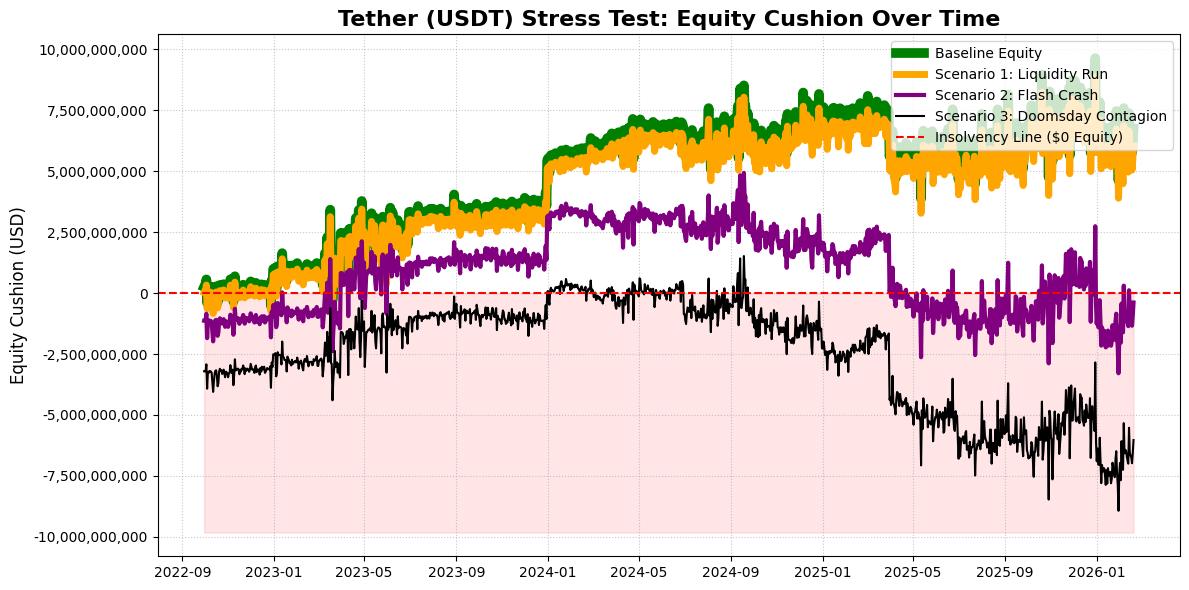

✅ Saved graph as circle_(usdc)_stress_test.png


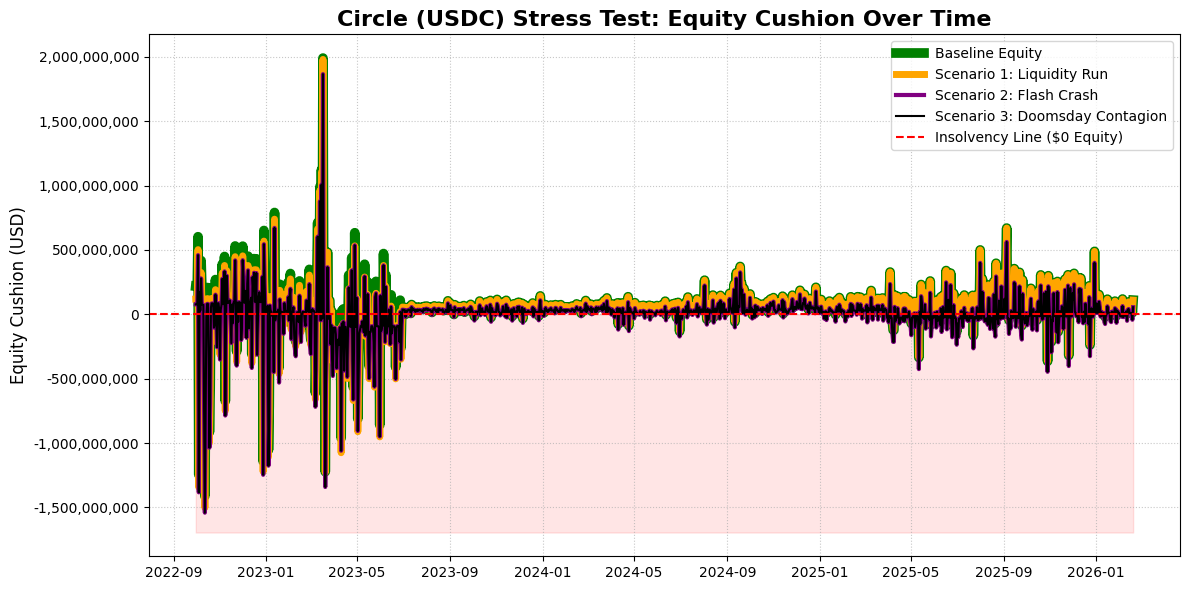

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. LOAD AND CLEAN DATA
df_tether = pd.read_csv("tetherassets.csv", header=0)
df_circle = pd.read_csv("circleassets.csv", header=0)

df_tether.columns = df_tether.columns.str.strip()
df_circle.columns = df_circle.columns.str.strip()

def clean_currency(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace(',', '').replace(' -   ', '0').strip()
        try:
            return float(x)
        except ValueError:
            return np.nan
    return x

# Clean numerical columns
for col in df_tether.columns:
    if col != 'Date':
        df_tether[col] = df_tether[col].apply(clean_currency)

for col in df_circle.columns:
    if col != 'Date':
        df_circle[col] = df_circle[col].apply(clean_currency)

df_tether['Date'] = pd.to_datetime(df_tether['Date']).dt.tz_localize(None)
df_tether.set_index('Date', inplace=True)

df_circle['Date'] = pd.to_datetime(df_circle['Date']).dt.tz_localize(None)
df_circle.set_index('Date', inplace=True)

# 2. STRESS TESTING USDT (TETHER)

def stress_test_tether(df):
    df_results = pd.DataFrame(index=df.index)

    # Base Equity
    df_results['Baseline Equity'] = df['New Estimate Reserves'] - df['USDT Market Cap']

    # --- Scenario 1: Liquidity Run ---
    withdrawal_amount = df['USDT Market Cap'] * 0.30
    liquid_assets = df['Cash + Banks Depo'].fillna(0) + df['O/n Repo MtM'].fillna(0)

    shortfall = np.maximum(0, withdrawal_amount - liquid_assets)
    fire_sale_loss = shortfall * 0.02
    df_results['Scenario 1: Liquidity Run'] = df_results['Baseline Equity'] - fire_sale_loss

    # --- Scenario 2: Market Flash Crash ---
    btc_loss = df.get('BTC Value', 0) * 0.50
    gold_loss = df.get('Gold Value', 0) * 0.15
    tbills_duration_loss = df.get('Tbills Notional', 0) * (df.get('Tbills Duration', 45) / 365) * 0.03

    total_market_loss = btc_loss + gold_loss + tbills_duration_loss
    df_results['Scenario 2: Flash Crash'] = df_results['Baseline Equity'] - total_market_loss

    # --- Scenario 3: Credit Contagion (Doomsday) ---
    corp_bonds = df.loc[:, df.columns.str.contains('Corporate Bonds')].sum(axis=1) if any(df.columns.str.contains('Corporate Bonds')) else 0

    corp_bond_loss = corp_bonds * 0.10
    secured_loan_loss = df.get('Secured Loans', 0) * 0.25
    other_inv_loss = df.get('Other inv', 0) * 0.50

    credit_loss = corp_bond_loss + secured_loan_loss + other_inv_loss
    df_results['Scenario 3: Doomsday Contagion'] = df_results['Baseline Equity'] - total_market_loss - credit_loss

    df = df.join(df_results)
    return df

# 3. STRESS TESTING USDC

def stress_test_circle(df):
    df_results = pd.DataFrame(index=df.index)

    # Base Equity (FIXED: Using New Estimate Reserves)
    df_results['Baseline Equity'] = df['New Estimate Reserves'] - df['USDC Market Cap']

    # --- Scenario 1: Liquidity Run ---
    withdrawal_amount = df['USDC Market Cap'] * 0.30
    liquid_assets = df['Cash & Deposits'].fillna(0) + df['O/N Repo'].fillna(0)

    shortfall = np.maximum(0, withdrawal_amount - liquid_assets)
    fire_sale_loss = shortfall * 0.02
    df_results['Scenario 1: Liquidity Run'] = df_results['Baseline Equity'] - fire_sale_loss

    # --- Scenario 2 & 3: Market/Credit Crash ---
    tbills_duration_loss = df.get('Tbills', 0) * (45 / 365) * 0.03
    df_results['Scenario 2: Flash Crash'] = df_results['Baseline Equity'] - tbills_duration_loss
    df_results['Scenario 3: Doomsday Contagion'] = df_results['Scenario 2: Flash Crash']

    df = df.join(df_results)
    return df

# Run Tests
tether_stress = stress_test_tether(df_tether)
circle_stress = stress_test_circle(df_circle)

# 4. PLOTTING THE RESULTS

def plot_stress_test(df, coin_name, color_map):
    fig, ax = plt.subplots(figsize=(12, 6))

    widths = {
        'Baseline Equity': 7.0,             # Thickest (Bottom layer)
        'Scenario 1: Liquidity Run': 5.0,   # Wide enough to peek out
        'Scenario 2: Flash Crash': 3.0,
        'Scenario 3: Doomsday Contagion': 1.5 # Thinnest (Top layer)
    }

    for col, color in color_map.items():
        ax.plot(df.index, df[col],
                label=col,
                color=color,
                linestyle='-',
                linewidth=widths[col])

    # Insolvency Threshold
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Insolvency Line ($0 Equity)')

    ax.set_title(f'{coin_name} Stress Test: Equity Cushion Over Time', fontsize=16, fontweight='bold')
    ax.set_ylabel('Equity Cushion (USD)', fontsize=12)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

    # Area below zero
    min_val = df[list(color_map.keys())].min().min()
    fill_bottom = min_val * 1.1 if min_val < 0 else -1e9
    ax.fill_between(df.index, 0, fill_bottom, color='red', alpha=0.1)

    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()

    file_name = f"{coin_name.replace(' ', '_').lower()}_stress_test.png"
    plt.savefig(file_name)
    print(f"✅ Saved graph as {file_name}")
    plt.show()

colors = {
    'Baseline Equity': 'green',
    'Scenario 1: Liquidity Run': 'orange',
    'Scenario 2: Flash Crash': 'purple',
    'Scenario 3: Doomsday Contagion': 'black'
}

plot_stress_test(tether_stress, "Tether (USDT)", colors)
plot_stress_test(circle_stress, "Circle (USDC)", colors)